In [1]:
from cresowlve.utils import read_json

model_results_path = "../experiments/outputs/gemini-3-flash-preview/chgk_en_benchmark_eval_reasoning_model_en_s0_gemini-3-flash-preview_20260302_151010.json"
benchmark_path = "../experiments/data/task/chgk_en_benchmark.json"
knowledge_path = "../experiments/data/task/chgk_benchmark_knowledge.json"
model_results = read_json(model_results_path)
benchmark = read_json(benchmark_path)
knowledge_results = read_json(knowledge_path)

In [3]:
len(set([kg for sample in knowledge_results["data"] for kg in sample.get("knowledge", [])]))

10293

<Axes: ylabel='Count'>

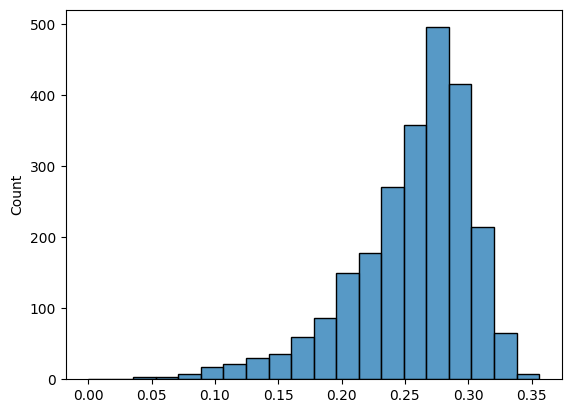

In [4]:
import seaborn as sns

max_kg_semdises = [s["max_knowledge_semdis"] for s in knowledge_results["data"]]

sns.histplot(max_kg_semdises, bins=20)

<Axes: ylabel='Count'>

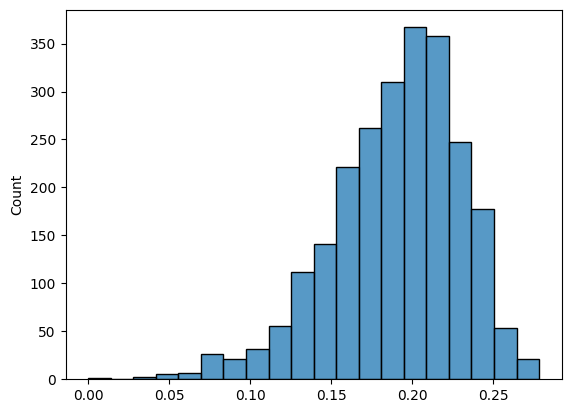

In [7]:
import seaborn as sns

max_kg_semdises = [s["knowledge_semdis"] for s in knowledge_results["data"]]

sns.histplot(max_kg_semdises, bins=20)

In [ ]:
from statistics import mean
import numpy as np
import random

kg_semdis_ranges = [(0, 0.17), (0.17, 0.19), (0.19, 0.2), (0.2, 0.22), (0.22, 0.24), (0.24, 0.26), (0.26, 0.28), (0.28, 0.3), (0.3, 0.32), (0.32, 1.0)]
kg_semdis_ranges = [(0, 0.17), (0.17, 0.19), (0.19, 0.2), (0.2, 0.22), (0.22, 0.24), (0.24, 0.26), (0.26, 0.28), (0.28, 0.3), (0.3, 0.32), (0.32, 1.0)]
# knowledge_semdis_ranges = np.quantile(max_kg_semdises, [0, 0.25, 0.5, 0.75, 1])
knowledge_semdis_accs = []
knowledge_semdis_range_ids = [[s["id"] for s in knowledge_results["data"] if r[0] <= s["max_knowledge_semdis"] < r[1]] for r in kg_semdis_ranges]
min_len = min(len(s) for s in knowledge_semdis_range_ids)
print(f"Min samples in a range: {min_len}")

for range_ids in knowledge_semdis_range_ids:
    print(f"Range {len(range_ids)} samples")
    range_ids = random.sample(range_ids, min_len)
    range_results = [s for s in model_results["data"] if s["id"] in range_ids]
    range_acc = mean([int(r.get("gpt-4o_judge_match", False)) for r in range_results])
    knowledge_semdis_accs.append(range_acc)

knowledge_semdis_accs

Min samples in a range: 58
Range 151 samples
Range 84 samples
Range 58 samples
Range 176 samples
Range 245 samples
Range 350 samples
Range 507 samples
Range 514 samples
Range 262 samples
Range 73 samples


[0.6379310344827587,
 0.5172413793103449,
 0.5172413793103449,
 0.43103448275862066,
 0.5344827586206896,
 0.4482758620689655,
 0.5344827586206896,
 0.41379310344827586,
 0.5517241379310345,
 0.6379310344827587]

<Axes: >

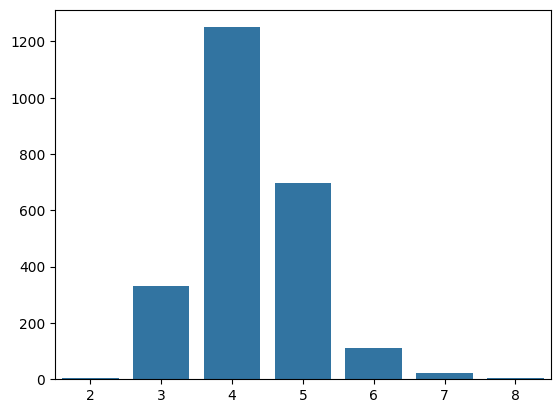

In [9]:
from collections import Counter
import seaborn as sns

knowledge_counts = Counter([len(s["knowledge"]) for s in knowledge_results["data"] if "knowledge" in s])

sns.barplot(x=list(knowledge_counts.keys()), y=list(knowledge_counts.values()))

In [11]:
from statistics import mean
import random
kg_lens = sorted(knowledge_counts.keys())
knowledge_lens = [3, 4, 5, 6]
min_count = min([knowledge_counts.get(l, 0) for l in kg_lens])

knowledge_accuracies = []

for k_len in kg_lens:
    knowledge_ids = [s["id"] for s in knowledge_results["data"] if len(s.get("knowledge", [])) == k_len]
    knowledge_ids = random.sample(knowledge_ids, min_count)
    k_results = [s for s in model_results["data"] if s["id"] in knowledge_ids]
    k_acc = mean([int(r.get("gpt-4o_judge_match", False)) for r in k_results])
    knowledge_accuracies.append(k_acc)

knowledge_accuracies

[0.5, 0.75, 0.25, 0.25, 0.75, 0.5, 1]

In [12]:
kg_semdis_lst = []
judge_match_lst = []

for sample in knowledge_results["data"]:
    if "max_knowledge_semdis" in sample:
        kg_semdis_lst.append(sample["max_knowledge_semdis"])
        model_sample = next((s for s in model_results["data"] if s["id"] == sample["id"]), None)
        if model_sample:
            judge_match_lst.append(int(model_sample.get("gpt-4o_judge_match", False)))

In [14]:
len(kg_semdis_lst), len(judge_match_lst)

(2420, 2420)

Text(0, 0.5, 'Accuracy')

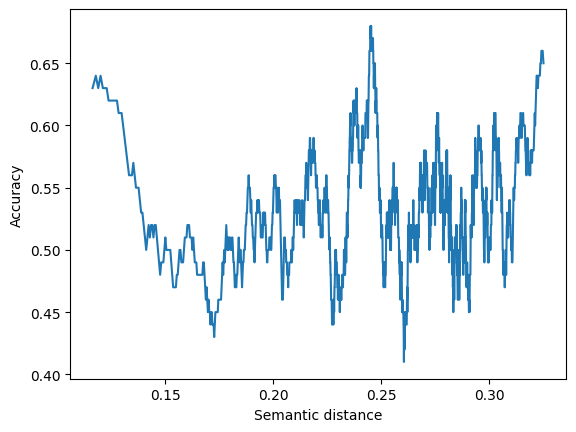

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

order = np.argsort(kg_semdis_lst)
x = np.array(kg_semdis_lst)[order]
y = np.array(judge_match_lst)[order]

k = 100  # window size

xs = []
accs = []

for i in range(len(x) - k):
    xs.append(x[i:i+k].mean())
    accs.append(y[i:i+k].mean())

plt.plot(xs, accs)
plt.xlabel("Semantic distance")
plt.ylabel("Accuracy")